# Asimetrías Materia-Antimateria Cota 01

## Leyendo datos de simulación

In [67]:
# Importando librerías necesarias
%matplotlib inline

from pathlib import Path
import warnings
import os

import numpy
import pandas
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.optimize import curve_fit as cf

warnings.filterwarnings("ignore")
pandas.set_option("display.max_columns", None)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"
GRAPHICS_DIR = BASE_DIR / "graficas"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

DARK_BACKGROUND = "#030315"
LIGHT_TEXT = "white"
ACCENT_CYAN = "#62d9ff"
ACCENT_GREEN = "#55d98b"
ACCENT_MAGENTA = "#ff70d5"

print(f"Directorio del proyecto: {BASE_DIR}")
print(f"Directorio de los datos: {DATA_DIR}")
print(f"Directorio de las gráficas: {GRAPHICS_DIR}")

Directorio del proyecto: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2
Directorio de los datos: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\Data
Directorio de las gráficas: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas


In [68]:
# ── Funciones auxiliares de estilo ─────────────────────────────────────────
def apply_dark_axes_style(fig, ax, title, xlabel, ylabel):
    """Aplica el diseño oscuro inspirado en la primera gráfica de referencia."""
    ax.set_facecolor(DARK_BACKGROUND)
    fig.patch.set_facecolor(DARK_BACKGROUND)

    ax.set_title(title, color=LIGHT_TEXT, pad=12, fontweight="bold")
    ax.set_xlabel(xlabel, color=LIGHT_TEXT)
    ax.set_ylabel(ylabel, color=LIGHT_TEXT)
    ax.tick_params(axis="both", colors=LIGHT_TEXT)

    for spine in ax.spines.values():
        spine.set_edgecolor(LIGHT_TEXT)


def add_dark_colorbar(fig, ax, image, label="Frecuencia"):
    """Crea una barra de color legible sobre fondo oscuro."""
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(label, color=LIGHT_TEXT)
    colorbar.ax.yaxis.set_tick_params(color=LIGHT_TEXT)
    plt.setp(colorbar.ax.yaxis.get_ticklabels(), color=LIGHT_TEXT)
    colorbar.outline.set_edgecolor(LIGHT_TEXT)
    return colorbar


def save_figure(fig, filename, dpi=150):
    """Guarda una figura sin recortar etiquetas y conserva su fondo."""
    output_path = GRAPHICS_DIR / filename
    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    print(f"Gráfica guardada en: {output_path}")

In [69]:
# Verificación de los archivos
data_files = {
    "simulation": DATA_DIR / "PhaseSpaceSimulation.root",
    "magnet_up": DATA_DIR / "B2HHH_MagnetUp.root",
    "magnet_down": DATA_DIR / "B2HHH_MagnetDown.root"
}
for name, path in data_files.items():
    status = "Encontado" if path.exists() else "No encontrado"
    print(f"{name}: {status} - {path}")

simulation: Encontado - c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\Data\PhaseSpaceSimulation.root
magnet_up: Encontado - c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\Data\B2HHH_MagnetUp.root
magnet_down: Encontado - c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\Data\B2HHH_MagnetDown.root


In [70]:
# Cargando los datos simulados como un marco de datos
with uproot.open("Data/PhaseSpaceSimulation.root:PhaseSpaceTree") as data:
    sim_data = data.arrays(data.keys(),library="pd")

In [71]:
# Lectura para la simulación (alternativa)
simulation_path = DATA_DIR / "PhaseSpaceSimulation.root"
with uproot.open(simulation_path) as root_file:
    simulation_tree = root_file["PhaseSpaceTree"]
    sim_data = simulation_tree.arrays(library = "pd")

In [72]:
# Creando una tabla de las variables de datos
sim_data.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,H2_PX,H2_PY,H2_PZ,H2_ProbK,H2_ProbPi,H2_Charge,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,0.0,1.0,3551.84,1636.96,23904.14,1.0,0.0,-1,1.0,0,41507.15,15980.59,331663.64,1.0,0.0,1,1.0,0,36100.40,16546.83,295600.61,1.0,0.0,-1,1.0,0
1,0.0,1.0,-2525.98,-5284.05,35822.00,1.0,0.0,1,1.0,0,-43182.91,-96553.03,585289.31,1.0,0.0,-1,1.0,0,-8648.32,-16617.56,98535.13,1.0,0.0,-1,1.0,0
2,0.0,1.0,-700.67,1299.73,8127.76,1.0,0.0,-1,1.0,0,-1411.99,3550.96,16120.27,1.0,0.0,1,1.0,0,-13483.34,10860.77,79787.59,1.0,0.0,1,1.0,0
3,0.0,1.0,3364.63,1397.30,222815.29,1.0,0.0,1,1.0,0,2192.42,1369.87,161924.75,1.0,0.0,-1,1.0,0,1925.16,-551.12,40420.96,1.0,0.0,1,1.0,0
4,0.0,1.0,-581.66,-1305.24,22249.59,1.0,0.0,-1,1.0,0,1153.05,-1998.17,66134.22,1.0,0.0,1,1.0,0,-2820.04,-8305.43,250130.00,1.0,0.0,-1,1.0,0


# Reconstrucción de Masa Invariante

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\01_momento_x_primer_kaon.png


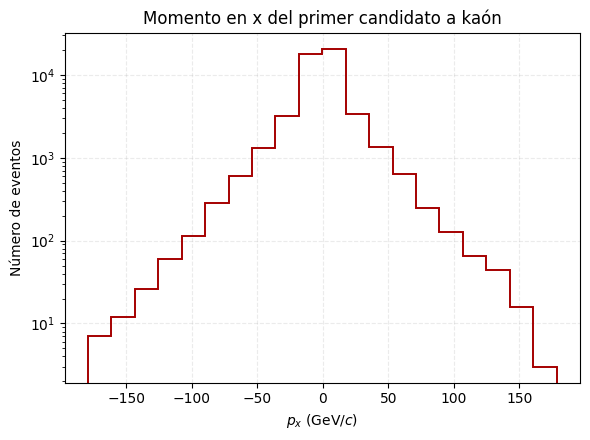

In [73]:
# Histograma de la componente H1_PX
h1px = sim_data["H1_PX"] / 1000.0

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    h1px,
    bins=20,
    range=(h1px.min(), h1px.max()),
    histtype="step",
    color="#a50000",
    linewidth=1.4
)
ax.set_xlabel(r"$p_x$ (GeV/$c$)")
ax.set_ylabel("Número de eventos")
ax.set_yscale("log")
ax.set_title("Momento en x del primer candidato a kaón")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "01_momento_x_primer_kaon.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\02_magnitud_momento_primer_kaon.png


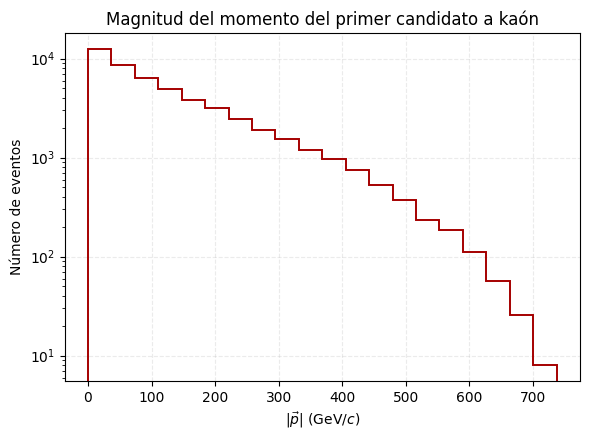

In [74]:
# Magnitud del momento del primer candidato a kaón
h1py = sim_data["H1_PY"] / 1000.0
h1pz = sim_data["H1_PZ"] / 1000.0
h1p = numpy.sqrt(h1px**2 + h1py**2 + h1pz**2)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    h1p,
    bins=20,
    range=(h1p.min(), h1p.max()),
    histtype="step",
    color="#a50000",
    linewidth=1.4
)
ax.set_xlabel(r"$|\vec{p}|$ (GeV/$c$)")
ax.set_ylabel("Número de eventos")
ax.set_yscale("log")
ax.set_title("Magnitud del momento del primer candidato a kaón")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "02_magnitud_momento_primer_kaon.png")
plt.show()

## Energía y Masa

In [75]:
# Cálculo de la energía del primer kaón
mKaon = 0.493 #GeV
h1E = numpy.sqrt(h1p*h1p+mKaon*mKaon)

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\03_energia_primer_kaon.png


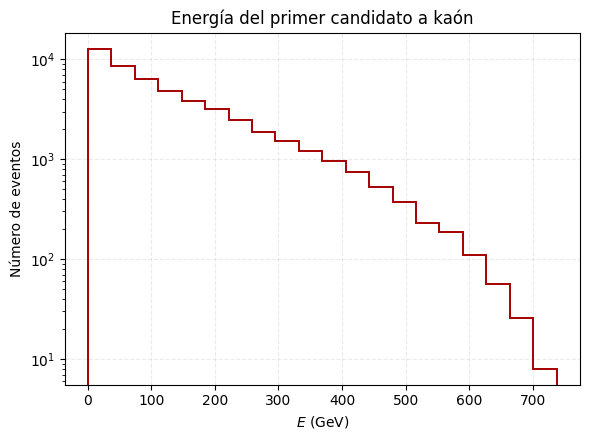

In [76]:
# Histograma de la energía del primer candidato a kaón
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    h1E,
    bins=20,
    range=(h1E.min(), h1E.max()),
    histtype="step",
    color="#a50000",
    linewidth=1.4
)
ax.set_xlabel(r"$E$ (GeV)")
ax.set_ylabel("Número de eventos")
ax.set_yscale("log")
ax.set_title("Energía del primer candidato a kaón")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "03_energia_primer_kaon.png")
plt.show()

Momentos y las energías del segundo y tercer candidato a kaón.

In [77]:
# Cálculo de variables para la energía de los otros dos kaones
h2px = sim_data["H2_PX"]/1000.0
h2py = sim_data["H2_PY"]/1000.0
h2pz = sim_data["H2_PZ"]/1000.0
# Energía del segundo kaón
h2E = numpy.sqrt(h2px*h2px+h2py*h2py+h2pz*h2pz+mKaon*mKaon)

In [78]:
# Variables de energía para el tercer kaón
h3px = sim_data["H3_PX"]/1000.0
h3py = sim_data["H3_PY"]/1000.0
h3pz = sim_data["H3_PZ"]/1000.0
# Energía del tercer Kaón
h3E = numpy.sqrt(h3px*h3px+h3py*h3py+h3pz*h3pz+mKaon*mKaon)

## Añadiendo características del mesón $B$

In [79]:
# calculate the energy of the B meson
BmE = h1E + h2E + h3E

In [80]:
# Cálculo de los componentes del momentum del mesón B y la magnitud del momentum del mesón B
Bmpx = h1px + h2px + h3px
Bmpy = h1py + h2py + h3py
Bmpz = h1pz + h2pz + h3pz
Bmp = numpy.sqrt(Bmpx*Bmpx + Bmpy*Bmpy + Bmpz*Bmpz)

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\04_masa_invariante_simulada_B.png


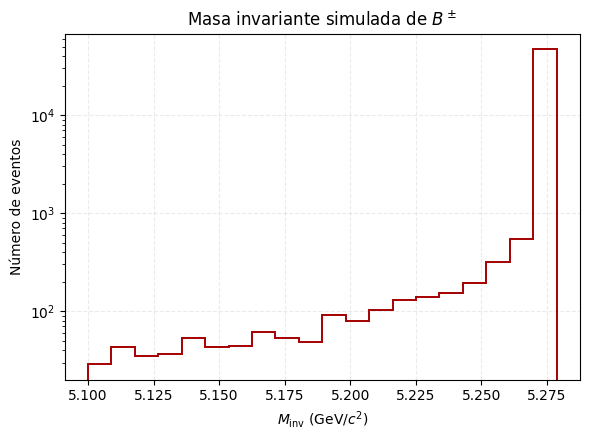

In [81]:
# Masa invariante reconstruida del mesón B en la simulación
MBm = numpy.sqrt(numpy.clip(BmE**2 - Bmp**2, 0, None))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    MBm,
    bins=20,
    range=(5.1, MBm.max()),
    histtype="step",
    color="#a50000",
    linewidth=1.4
)
ax.set_xlabel(r"$M_{\mathrm{inv}}$ (GeV/$c^2$)")
ax.set_ylabel("Número de eventos")
ax.set_yscale("log")
ax.set_title(r"Masa invariante simulada de $B^\pm$")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "04_masa_invariante_simulada_B.png")
plt.show()

# Trabajando con datos reales y aplicando cortes (cuts)

In [82]:
# Preselección de valores
preselection = "(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0) & (H1_ProbPi<0.5) & (H2_ProbPi<0.5) & (H3_ProbPi<0.5) & (H1_ProbK>0.5) & (H2_ProbK>0.5) & (H3_ProbK>0.5)"

### Lectura portable de los dos archivos

La versión original usaba `real_data._append(...)` sin reasignar el resultado. Ese método no modifica el `DataFrame` existente y, por ello, podía conservar únicamente `MagnetUp`. En las siguientes celdas se usa una función de lectura y `pandas.concat`, aplicando la misma preselección a ambos archivos.

In [83]:
# Códico alternativo
def load_decay_tree(file_path: Path, cut: str | None = None) -> pandas.DataFrame:
    """Cargando el arbol DecayTree de un archivo ROOT como DataFrame"""
    if not file_path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo: {file_path}"
        )
    with uproot.open(file_path) as root_file:
        if "DecayTree" not in root_file:
            raise KeyError(
                f"El archivo {file_path.name} no contiene un árbol DecayTree"
            )
        tree = root_file["DecayTree"]
        return tree.arrays(
            expressions = tree.keys(),
            cut = cut,
            library="pd"
        )

In [84]:
magnet_up_data = load_decay_tree(DATA_DIR / "B2HHH_MagnetUp.root", cut=preselection)
magnet_down_data = load_decay_tree(DATA_DIR / "B2HHH_MagnetDown.root", cut=preselection)
real_data = pandas.concat(
    [magnet_up_data, magnet_down_data],
    ignore_index=True
)
print(f"Eventos combinados: {len(real_data):,}")
print(f"Eventos Magnet Up: {len(magnet_up_data):,}")
print(f"Eventos Magnet Down: {len(magnet_down_data):,}")

Eventos combinados: 23,895
Eventos Magnet Up: 9,717
Eventos Magnet Down: 14,178


Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\05_probK_combinada.png


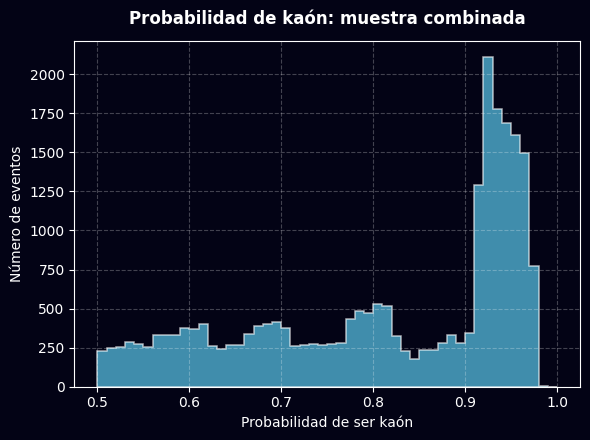

In [85]:
# Distribución de H1_ProbK
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    real_data["H1_ProbK"],
    bins=50,
    range=(0.5, 1.0),
    histtype="stepfilled",
    color="#62d9ff",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de kaón: muestra combinada",
    "Probabilidad de ser kaón",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "05_probK_combinada.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\06_probK_magnet_up.png


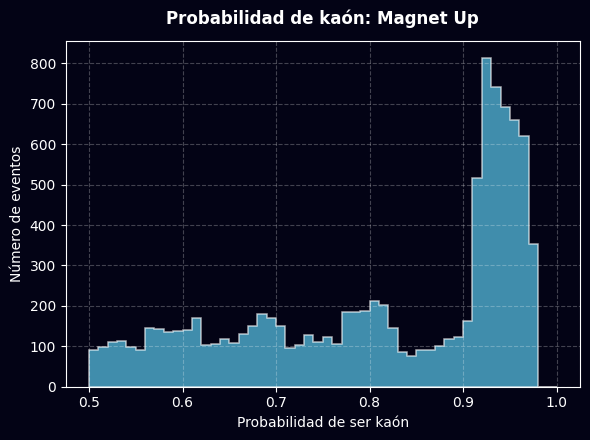

In [86]:
# Distribución de H1_ProbK
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_up_data["H1_ProbK"],
    bins=50,
    range=(0.5, 1.0),
    histtype="stepfilled",
    color="#62d9ff",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de kaón: Magnet Up",
    "Probabilidad de ser kaón",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "06_probK_magnet_up.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\07_probK_magnet_down.png


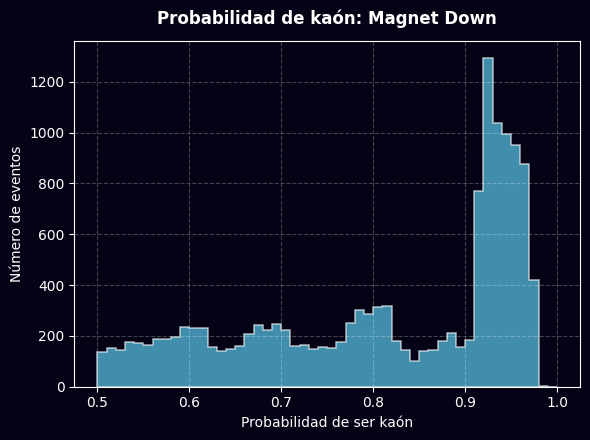

In [87]:
# Distribución de H1_ProbK
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_down_data["H1_ProbK"],
    bins=50,
    range=(0.5, 1.0),
    histtype="stepfilled",
    color="#62d9ff",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de kaón: Magnet Down",
    "Probabilidad de ser kaón",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "07_probK_magnet_down.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\08_probPi_combinada.png


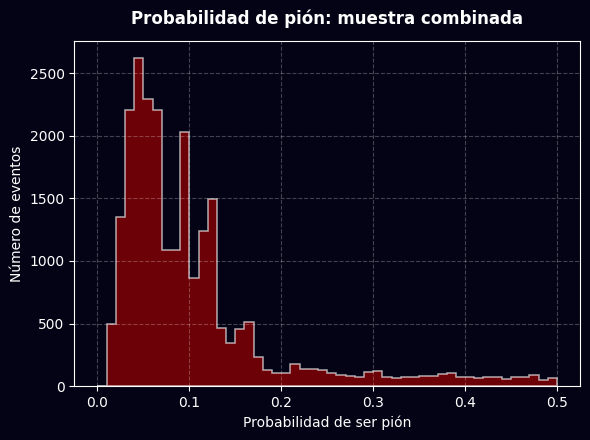

In [88]:
# Distribución de H1_ProbPi
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    real_data["H1_ProbPi"],
    bins=50,
    range=(0.0, 0.5),
    histtype="stepfilled",
    color="#a50000",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de pión: muestra combinada",
    "Probabilidad de ser pión",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "08_probPi_combinada.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\09_probPi_magnet_up.png


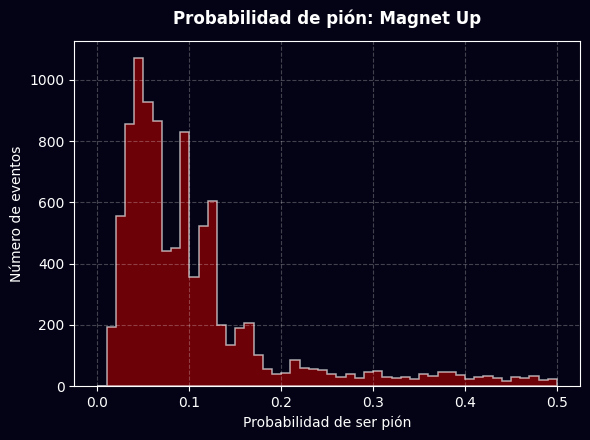

In [89]:
# Distribución de H1_ProbPi
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_up_data["H1_ProbPi"],
    bins=50,
    range=(0.0, 0.5),
    histtype="stepfilled",
    color="#a50000",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de pión: Magnet Up",
    "Probabilidad de ser pión",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "09_probPi_magnet_up.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\10_probPi_magnet_down.png


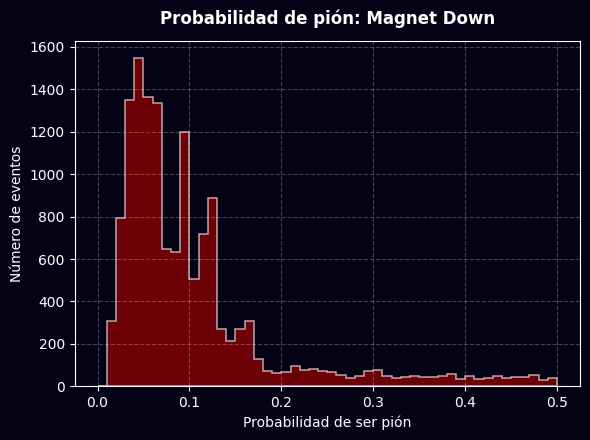

In [90]:
# Distribución de H1_ProbPi
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_down_data["H1_ProbPi"],
    bins=50,
    range=(0.0, 0.5),
    histtype="stepfilled",
    color="#a50000",
    edgecolor="white",
    linewidth=1.1,
    alpha=0.65
)
apply_dark_axes_style(
    fig,
    ax,
    "Probabilidad de pión: Magnet Down",
    "Probabilidad de ser pión",
    "Número de eventos"
)
ax.grid(color="white", linestyle="--", alpha=0.25)
fig.tight_layout()
save_figure(fig, "10_probPi_magnet_down.png")
plt.show()

### Diseño 2D de probabilidades

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\11_probabilidades_2d_combinada.png


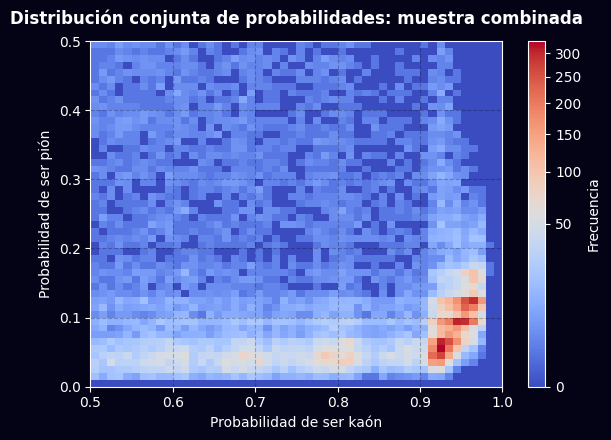

In [91]:
# Histograma 2D: diseño adaptado de la primera gráfica de graficas_uproot.ipynb
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor(DARK_BACKGROUND)

counts_2d, xedges, yedges, image = ax.hist2d(
    real_data["H1_ProbK"],       # eje x
    real_data["H1_ProbPi"],      # eje y
    bins=50,                   # 50 divisiones por eje
    range=[[0.5, 1.0], [0.0, 0.5]],
    cmap="coolwarm",
    norm=mcolors.PowerNorm(gamma=0.4)
)

ax.grid(color="#000000", linestyle="--", alpha=0.25)
add_dark_colorbar(fig, ax, image, label="Frecuencia")
apply_dark_axes_style(
    fig,
    ax,
    "Distribución conjunta de probabilidades: muestra combinada",
    "Probabilidad de ser kaón",
    "Probabilidad de ser pión"
)

fig.tight_layout()
save_figure(fig, "11_probabilidades_2d_combinada.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\12_probabilidades_2d_magnet_up.png


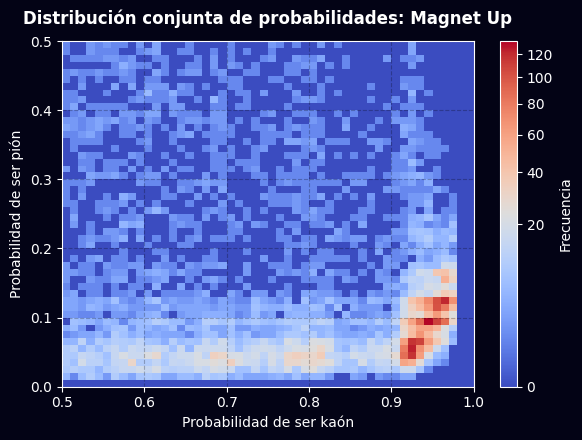

In [92]:
# Histograma 2D: diseño adaptado de la primera gráfica de graficas_uproot.ipynb
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor(DARK_BACKGROUND)

counts_2d, xedges, yedges, image = ax.hist2d(
    magnet_up_data["H1_ProbK"],       # eje x
    magnet_up_data["H1_ProbPi"],      # eje y
    bins=50,                   # 50 divisiones por eje
    range=[[0.5, 1.0], [0.0, 0.5]],
    cmap="coolwarm",
    norm=mcolors.PowerNorm(gamma=0.4)
)

ax.grid(color="#000000", linestyle="--", alpha=0.25)
add_dark_colorbar(fig, ax, image, label="Frecuencia")
apply_dark_axes_style(
    fig,
    ax,
    "Distribución conjunta de probabilidades: Magnet Up",
    "Probabilidad de ser kaón",
    "Probabilidad de ser pión"
)

fig.tight_layout()
save_figure(fig, "12_probabilidades_2d_magnet_up.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\13_probabilidades_2d_magnet_down.png


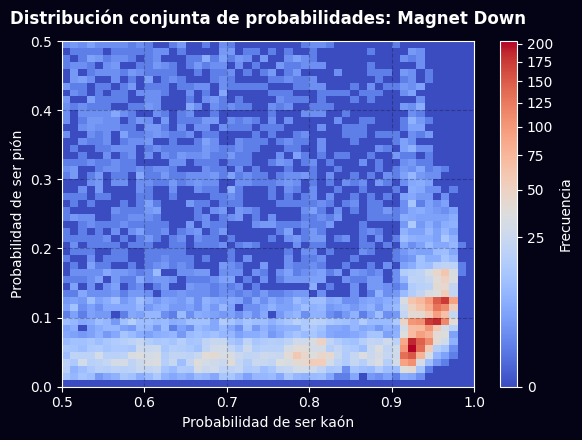

In [93]:
# Histograma 2D: diseño adaptado de la primera gráfica de graficas_uproot.ipynb
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor(DARK_BACKGROUND)

counts_2d, xedges, yedges, image = ax.hist2d(
    magnet_down_data["H1_ProbK"],       # eje x
    magnet_down_data["H1_ProbPi"],      # eje y
    bins=50,                   # 50 divisiones por eje
    range=[[0.5, 1.0], [0.0, 0.5]],
    cmap="coolwarm",
    norm=mcolors.PowerNorm(gamma=0.4)
)

ax.grid(color="#000000", linestyle="--", alpha=0.25)
add_dark_colorbar(fig, ax, image, label="Frecuencia")
apply_dark_axes_style(
    fig,
    ax,
    "Distribución conjunta de probabilidades: Magnet Down",
    "Probabilidad de ser kaón",
    "Probabilidad de ser pión"
)

fig.tight_layout()
save_figure(fig, "13_probabilidades_2d_magnet_down.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\14_masa_invariante_combinada.png


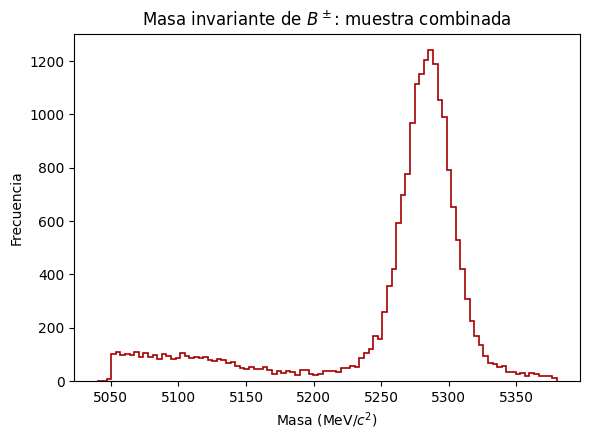

In [94]:
massKaon = 493.68  # MeV/c²
for hadron in ("H1", "H2", "H3"):
    real_data[f"{hadron}_E"] = numpy.sqrt(
        massKaon**2
        + real_data[f"{hadron}_PX"]**2
        + real_data[f"{hadron}_PY"]**2
        + real_data[f"{hadron}_PZ"]**2
    )

real_data["B_M"] = numpy.sqrt(numpy.clip(
    (real_data["H1_E"] + real_data["H2_E"] + real_data["H3_E"])**2
    - (real_data["H1_PX"] + real_data["H2_PX"] + real_data["H3_PX"])**2
    - (real_data["H1_PY"] + real_data["H2_PY"] + real_data["H3_PY"])**2
    - (real_data["H1_PZ"] + real_data["H2_PZ"] + real_data["H3_PZ"])**2,
    0,
    None
))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    real_data["B_M"],
    bins=100,
    range=(5040, 5380),
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"Masa (MeV/$c^2$)")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Masa invariante de $B^\pm$: muestra combinada")
ax.grid(False)
fig.tight_layout()
save_figure(fig, "14_masa_invariante_combinada.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\15_masa_invariante_magnet_up.png


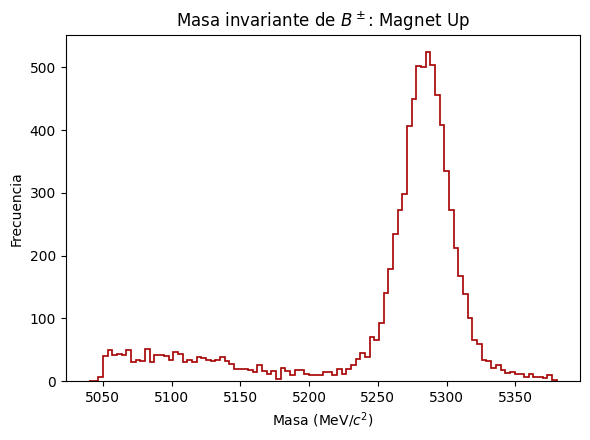

In [95]:
massKaon = 493.68  # MeV/c²
for hadron in ("H1", "H2", "H3"):
    magnet_up_data[f"{hadron}_E"] = numpy.sqrt(
        massKaon**2
        + magnet_up_data[f"{hadron}_PX"]**2
        + magnet_up_data[f"{hadron}_PY"]**2
        + magnet_up_data[f"{hadron}_PZ"]**2
    )

magnet_up_data["B_M"] = numpy.sqrt(numpy.clip(
    (magnet_up_data["H1_E"] + magnet_up_data["H2_E"] + magnet_up_data["H3_E"])**2
    - (magnet_up_data["H1_PX"] + magnet_up_data["H2_PX"] + magnet_up_data["H3_PX"])**2
    - (magnet_up_data["H1_PY"] + magnet_up_data["H2_PY"] + magnet_up_data["H3_PY"])**2
    - (magnet_up_data["H1_PZ"] + magnet_up_data["H2_PZ"] + magnet_up_data["H3_PZ"])**2,
    0,
    None
))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_up_data["B_M"],
    bins=100,
    range=(5040, 5380),
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"Masa (MeV/$c^2$)")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Masa invariante de $B^\pm$: Magnet Up")
ax.grid(False)
fig.tight_layout()
save_figure(fig, "15_masa_invariante_magnet_up.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\16_masa_invariante_magnet_down.png


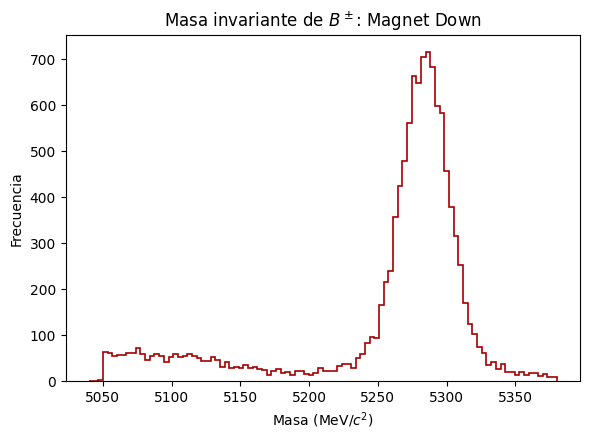

In [96]:
massKaon = 493.68  # MeV/c²
for hadron in ("H1", "H2", "H3"):
    magnet_down_data[f"{hadron}_E"] = numpy.sqrt(
        massKaon**2
        + magnet_down_data[f"{hadron}_PX"]**2
        + magnet_down_data[f"{hadron}_PY"]**2
        + magnet_down_data[f"{hadron}_PZ"]**2
    )

magnet_down_data["B_M"] = numpy.sqrt(numpy.clip(
    (magnet_down_data["H1_E"] + magnet_down_data["H2_E"] + magnet_down_data["H3_E"])**2
    - (magnet_down_data["H1_PX"] + magnet_down_data["H2_PX"] + magnet_down_data["H3_PX"])**2
    - (magnet_down_data["H1_PY"] + magnet_down_data["H2_PY"] + magnet_down_data["H3_PY"])**2
    - (magnet_down_data["H1_PZ"] + magnet_down_data["H2_PZ"] + magnet_down_data["H3_PZ"])**2,
    0,
    None
))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    magnet_down_data["B_M"],
    bins=100,
    range=(5040, 5380),
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"Masa (MeV/$c^2$)")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Masa invariante de $B^\pm$: Magnet Down")
ax.grid(False)
fig.tight_layout()
save_figure(fig, "16_masa_invariante_magnet_down.png")
plt.show()

# Buscando diferencias globales entre materia y antimateria

In [97]:
# Variable para la carga de los mesones B
real_data = real_data.eval('B_Charge = H1_Charge + H2_Charge + H3_Charge')

In [98]:
# Variables para s números de mesones B positivos y negativos
# Np = sum(real_data['B_Charge']>0)
Np = len(real_data.query('B_Charge == 1'))
# Nm = sum(real_data['B_Charge']<0)
Nm = len(real_data.query('B_Charge == -1'))
print(Np, Nm, Np-Nm)

12390 11505 885


In [99]:
# Cálculo del valor de la asimetría
A = (Nm-Np)/(Nm+Np)
print("A = ",A)

A =  -0.037037037037037035


### Estimando la significancia de la desviación

In [100]:
# calculate the statistical significance of your result and print it
sigma_A = numpy.sqrt((1-A**2)/(Nm+Np))
significance = A/sigma_A
print("Significancia estadística de la asimetría, sigma_A =",significance)

Significancia estadística de la asimetría, sigma_A = -5.729118797668817


# Diagramas de Dalitz y resonancias de dos cuerpos

In [101]:
# Cálculo de las masas invariantes para cada posible combinación de pares de hadrones
R02_m2 = (h1E+h3E)**2 - (h1px+h3px)**2 - (h1py+h3py)**2 - (h1pz+h3pz)**2
R03_m2 = (h1E+h2E)**2 - (h1px+h2px)**2 - (h1py+h2py)**2 - (h1pz+h2pz)**2

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\21_masa_invariante_par_simulacion.png


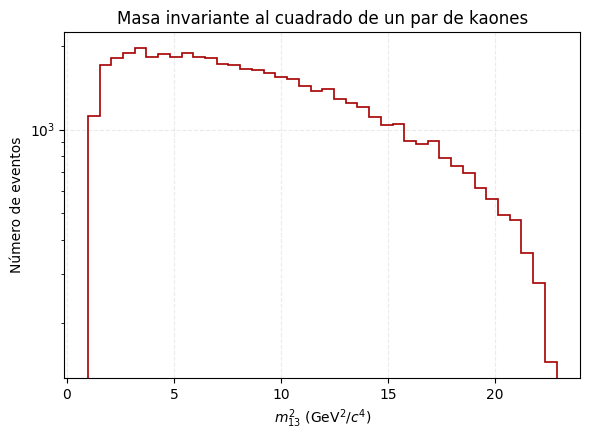

In [102]:
# Distribución de una masa invariante de dos cuerpos en la simulación
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    R02_m2,
    bins=40,
    range=(R02_m2.min(), R02_m2.max()),
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"$m_{13}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel("Número de eventos")
ax.set_yscale("log")
ax.set_title("Masa invariante al cuadrado de un par de kaones")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "21_masa_invariante_par_simulacion.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\22_dalitz_simulacion.png


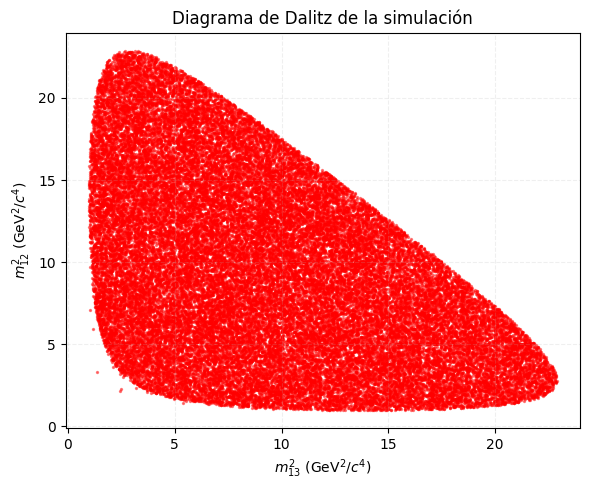

In [103]:
# Diagrama de Dalitz para los datos simulados
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    R02_m2,
    R03_m2,
    s=2.0,
    color="red",
    alpha=0.45,
    rasterized=True
)
ax.set_xlabel(r"$m_{13}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{12}^{2}$ (GeV$^2/c^4$)")
ax.set_title("Diagrama de Dalitz de la simulación")
ax.grid(alpha=0.2, linestyle="--")
fig.tight_layout()
save_figure(fig, "22_dalitz_simulacion.png")
plt.show()

## Añadiendo el diagrama de Dalitz para datos reales

In [104]:
# Cálculo de las masas invariantes para cada posible combinación de pares de hadrones en los datos reales
real_data = real_data.query('(B_M>5194) & (B_M<5364)')
real_data = real_data.eval('R02_m2 = (H1_E+H3_E)**2 - (H1_PX+H3_PX)**2 - (H1_PY+H3_PY)**2 - (H1_PZ+H3_PZ)**2')
real_data = real_data.eval('R03_m2 = (H1_E+H2_E)**2 - (H1_PX+H2_PX)**2 - (H1_PY+H2_PY)**2 - (H1_PZ+H2_PZ)**2')

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\23_dalitz_datos_reales.png


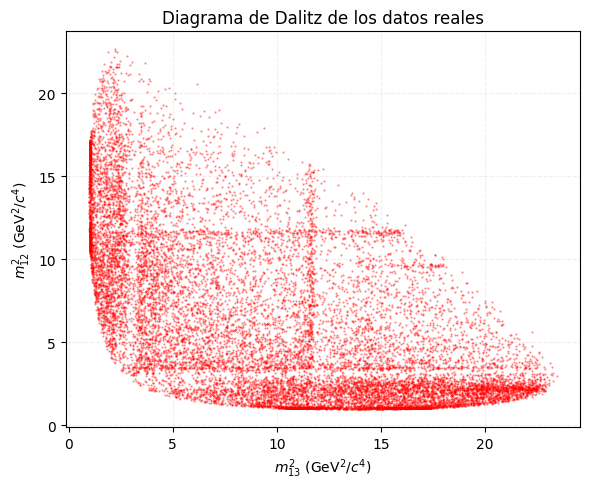

In [105]:
# Diagrama de Dalitz para los datos reales con preselección
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    real_data["R02_m2"] / 1e6,
    real_data["R03_m2"] / 1e6,
    s=0.3,
    color="red",
    alpha=0.45,
    rasterized=True
)
ax.set_xlabel(r"$m_{13}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{12}^{2}$ (GeV$^2/c^4$)")
ax.set_title("Diagrama de Dalitz de los datos reales")
ax.grid(alpha=0.2, linestyle="--")
fig.tight_layout()
save_figure(fig, "23_dalitz_datos_reales.png")
plt.show()

### Ordenando las variables de Dalitz

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\24_dalitz_ordenado.png


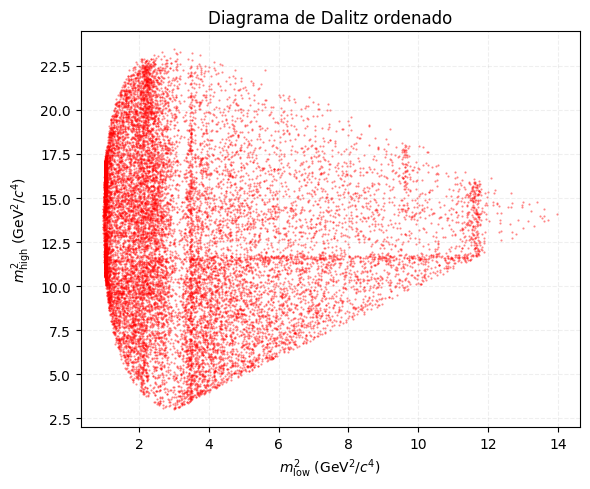

In [106]:
# Diagrama de Dalitz ordenado
R0low = real_data[["R02_m2", "R03_m2"]].min(axis=1)
R0high = real_data[["R02_m2", "R03_m2"]].max(axis=1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    R0low / 1e6,
    R0high / 1e6,
    s=0.3,
    color="red",
    alpha=0.45,
    rasterized=True
)
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title("Diagrama de Dalitz ordenado")
ax.grid(alpha=0.2, linestyle="--")
fig.tight_layout()
save_figure(fig, "24_dalitz_ordenado.png")
plt.show()

### Diagrama de Dalitz con intervalos (binned)
Puedes mejorar la representación de tu diagrama de Dalitz agrupando los datos en intervalos (bins). La función hist2d se puede usar para hacer un histograma 2D. La especificación del número de intervalos (bins) en la función hist2d es el número de intervalos en un eje.

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\25_dalitz_agrupado.png


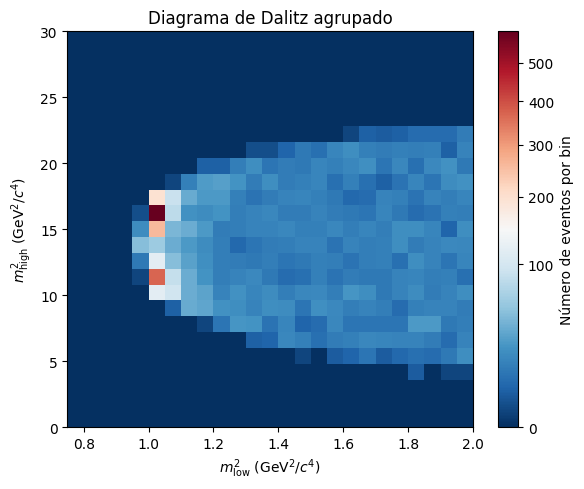

In [107]:
# Diagrama de Dalitz agrupado en bins
fig, ax = plt.subplots(figsize=(6, 5))
histogram_2d, xbins_dalitz, ybins_dalitz, image = ax.hist2d(
    R0low / 1e6,
    R0high / 1e6,
    bins=25,
    range=[[0.75, 2.0], [0.0, 30.0]],
    cmap="RdBu_r",
    norm=mcolors.PowerNorm(gamma=0.5)
)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Número de eventos por bin")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title("Diagrama de Dalitz agrupado")
fig.tight_layout()
save_figure(fig, "25_dalitz_agrupado.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\26_proyeccion_masa_low.png


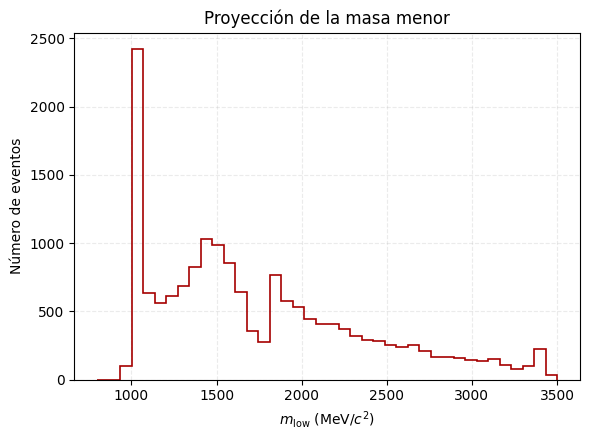

In [108]:
# Proyección de la masa menor del par de kaones
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    numpy.sqrt(R0low),
    bins=40,
    range=(800, 3500),
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"$m_{\mathrm{low}}$ (MeV/$c^2$)")
ax.set_ylabel("Número de eventos")
ax.set_title("Proyección de la masa menor")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "26_proyeccion_masa_low.png")
plt.show()

## Resonancias de dos cuerpos


Ahora puedes usar tu diagrama de Dalitz para identificar las resonancias intermedias que ves en tus gráficos. Las resonancias aparecerán como bandas de mayor densidad de puntos en los gráficos. Puedes usar las tablas de mesones del [Particle Data Group](http://pdg.lbl.gov/2015/tables/contents_tables.html) para identificar a qué partículas corresponden. Las tablas proporcionan las masas y anchos de las partículas y sus modos de desintegración. Buscas mesones con masas que correspondan a donde ves las bandas y que se desintegren en K<sup>+</sup>K<sup>-</sup>.

**¡Felicitaciones!** Has creado exitosamente un diagrama de Dalitz y lo has usado para observar la presencia de partículas intermedias en la desintegración de tu mesón B cargado en tres kaones cargados.

# Buscando diferencias locales entre materia y antimateria

## Eliminando resonancias de charm

## Comparando diagramas de Dalitz

In [109]:
# Eliminando las resonancias charm
# real_data = real_data.query('(sqrt(B_m2)<5330) & (sqrt(B_m2)>5228)')
real_data = real_data.query('((R02_m2<R03_m2) & ( (R02_m2<1800**2) | (R02_m2>2000**2))) | ((R02_m2>R03_m2) & ( (R03_m2<1800**2) | (R03_m2>2000**2)))')
Bp_real_data = real_data.query('(B_Charge == 1)')
R0low = Bp_real_data[['R02_m2','R03_m2']].min(axis=1)
R0high = Bp_real_data[['R02_m2','R03_m2']].max(axis=1)

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\27_dalitz_B_plus.png


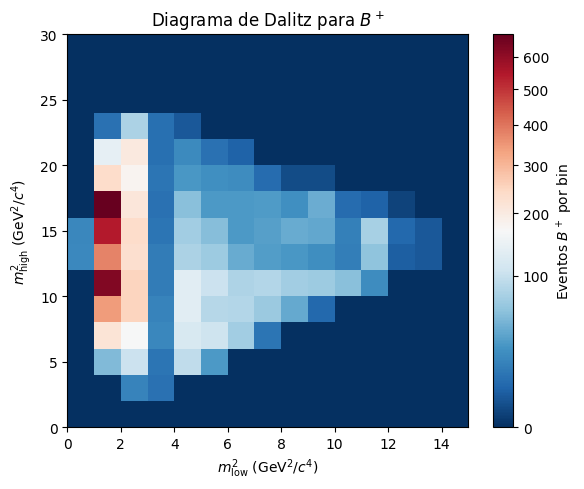

In [110]:
# Diagrama de Dalitz binned para eventos B+
fig, ax = plt.subplots(figsize=(6, 5))
hBp, xbins, ybins, image_Bp = ax.hist2d(
    R0low / 1e6,
    R0high / 1e6,
    bins=[15, 15],
    range=[[0, 15], [0, 30]],
    cmap="RdBu_r",
    norm=mcolors.PowerNorm(gamma=0.5)
)
colorbar = fig.colorbar(image_Bp, ax=ax)
colorbar.set_label("Eventos $B^+$ por bin")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title(r"Diagrama de Dalitz para $B^+$")
fig.tight_layout()
save_figure(fig, "27_dalitz_B_plus.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\28_dalitz_B_minus.png


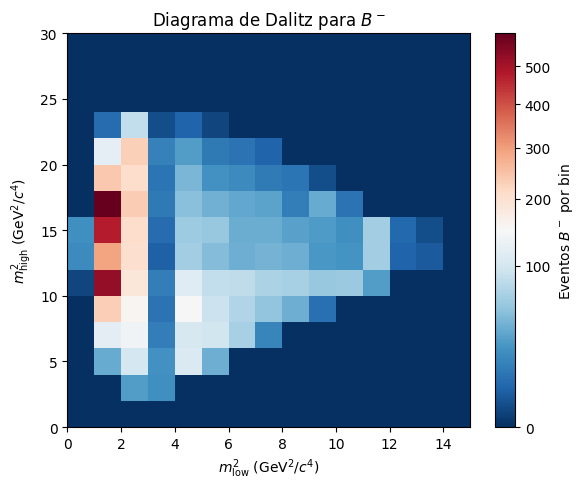

In [111]:
# Diagrama de Dalitz binned para eventos B-
Bm_real_data = real_data.query("B_Charge == -1")
R0low = Bm_real_data[["R02_m2", "R03_m2"]].min(axis=1)
R0high = Bm_real_data[["R02_m2", "R03_m2"]].max(axis=1)

fig, ax = plt.subplots(figsize=(6, 5))
hBm, xbins, ybins, image_Bm = ax.hist2d(
    R0low / 1e6,
    R0high / 1e6,
    bins=[15, 15],
    range=[[0, 15], [0, 30]],
    cmap="RdBu_r",
    norm=mcolors.PowerNorm(gamma=0.5)
)
colorbar = fig.colorbar(image_Bm, ax=ax)
colorbar.set_label("Eventos $B^-$ por bin")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title(r"Diagrama de Dalitz para $B^-$")
fig.tight_layout()
save_figure(fig, "28_dalitz_B_minus.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\29_asimetria_local.png


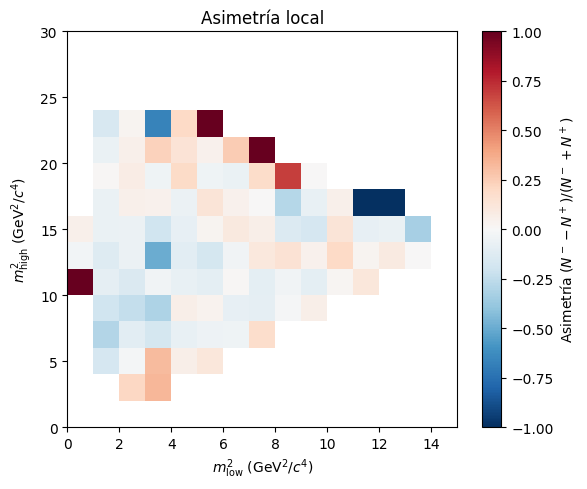

In [112]:
# Asimetría local entre los histogramas B- y B+
with numpy.errstate(divide="ignore", invalid="ignore"):
    A = numpy.where(
        hBm + hBp > 0,
        (hBm - hBp) / (hBm + hBp),
        numpy.nan
    )

fig, ax = plt.subplots(figsize=(6, 5))
image_asymmetry = ax.matshow(
    A.T,
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)
colorbar = fig.colorbar(image_asymmetry, ax=ax)
colorbar.set_label(r"Asimetría $(N^- - N^+)/(N^- + N^+)$")
ax.xaxis.set_ticks_position("bottom")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title("Asimetría local")
fig.tight_layout()
save_figure(fig, "29_asimetria_local.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\30_incertidumbre_asimetria_local.png


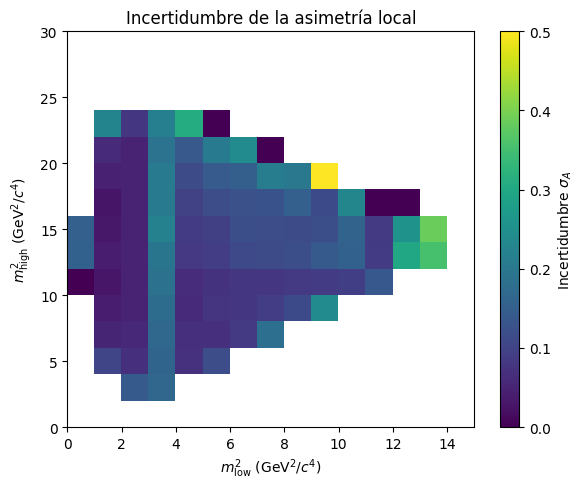

In [113]:
# Incertidumbre estadística de la asimetría local
with numpy.errstate(divide="ignore", invalid="ignore"):
    sigma_A = numpy.where(
        hBm + hBp > 0,
        numpy.sqrt((1 - A**2) / (hBm + hBp)),
        numpy.nan
    )

fig, ax = plt.subplots(figsize=(6, 5))
image_uncertainty = ax.matshow(
    sigma_A.T,
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    aspect="auto",
    origin="lower",
    cmap="viridis"
)
colorbar = fig.colorbar(image_uncertainty, ax=ax)
colorbar.set_label(r"Incertidumbre $\sigma_A$")
ax.xaxis.set_ticks_position("bottom")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title(r"Incertidumbre de la asimetría local")
fig.tight_layout()
save_figure(fig, "30_incertidumbre_asimetria_local.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\31_significancia_asimetria_local.png


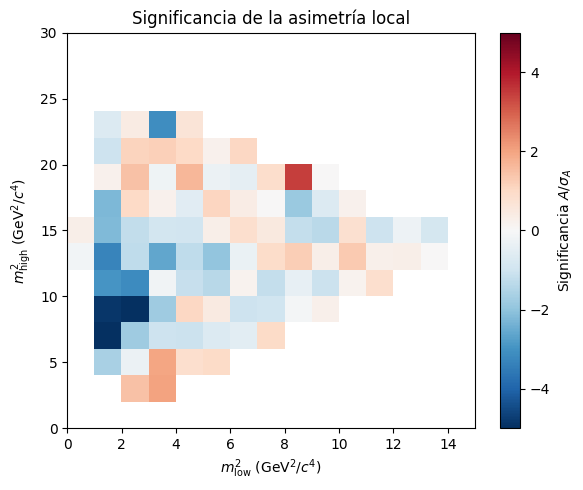

In [114]:
# Significancia estadística de la asimetría
with numpy.errstate(divide="ignore", invalid="ignore"):
    significance = numpy.where(
        sigma_A > 0,
        A / sigma_A,
        numpy.nan
    )

fig, ax = plt.subplots(figsize=(6, 5))
image_significance = ax.matshow(
    significance.T,
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-5,
    vmax=5
)
colorbar = fig.colorbar(image_significance, ax=ax)
colorbar.set_label(r"Significancia $A/\sigma_A$")
ax.xaxis.set_ticks_position("bottom")
ax.set_xlabel(r"$m_{\mathrm{low}}^{2}$ (GeV$^2/c^4$)")
ax.set_ylabel(r"$m_{\mathrm{high}}^{2}$ (GeV$^2/c^4$)")
ax.set_title(r"Significancia de la asimetría local")
fig.tight_layout()
save_figure(fig, "31_significancia_asimetria_local.png")
plt.show()

## Observando violación CP

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\32_masa_region_gran_CPV.png


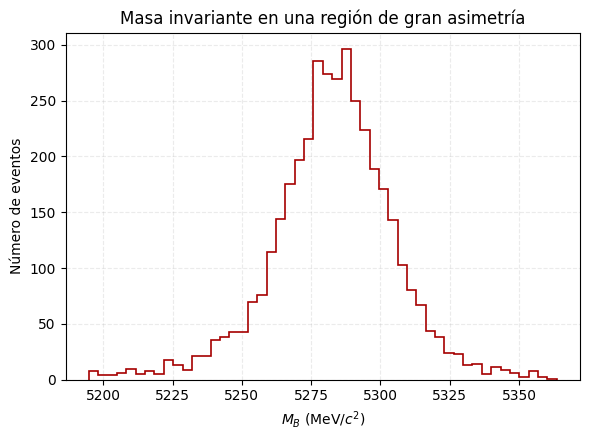

In [115]:
# Región del Dalitz plot con asimetría CP considerable
real_data_largeCPV = real_data.query(
    "((R02_m2 < R03_m2) & "
    "(R02_m2 > 1E6) & (R02_m2 < 2E6) & (R03_m2 < 16E6)) | "
    "((R02_m2 > R03_m2) & "
    "(R03_m2 > 1E6) & (R03_m2 < 2E6) & (R02_m2 < 16E6))"
)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    real_data_largeCPV["B_M"],
    bins=50,
    histtype="step",
    color="#a50000",
    linewidth=1.2
)
ax.set_xlabel(r"$M_B$ (MeV/$c^2$)")
ax.set_ylabel("Número de eventos")
ax.set_title("Masa invariante en una región de gran asimetría")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "32_masa_region_gran_CPV.png")
plt.show()

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\33_comparacion_masa_B_plus_B_minus.png


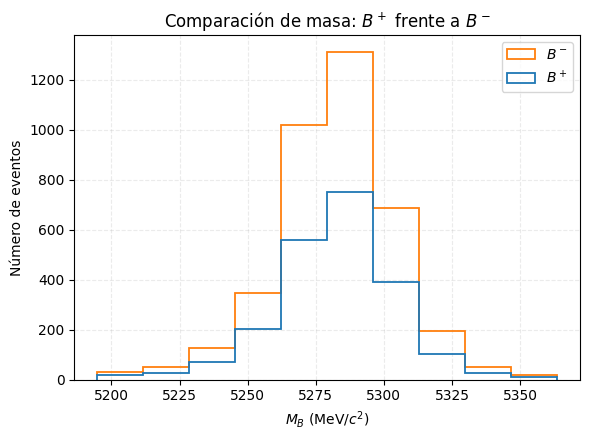

In [116]:
# Comparación directa de B+ y B- en la misma región
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    [
        real_data_largeCPV.query("B_Charge == 1")["B_M"],
        real_data_largeCPV.query("B_Charge == -1")["B_M"]
    ],
    bins=10,
    histtype="step",
    stacked=True,
    fill=False,
    linewidth=1.3,
    label=[r"$B^+$", r"$B^-$"]
)
ax.legend()
ax.set_xlabel(r"$M_B$ (MeV/$c^2$)")
ax.set_ylabel("Número de eventos")
ax.set_title(r"Comparación de masa: $B^+$ frente a $B^-$")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
save_figure(fig, "33_comparacion_masa_B_plus_B_minus.png")
plt.show()

## Añadiendo sofisticación adicional
### Ajustando la masa

In [117]:
fit_data = real_data.copy()
mkaon = 493.677 # MeV/c^2
for hadron in ("H1", "H2", "H3"):
    momentum_squared = (
        fit_data[f"{hadron}_PX"]**2 + fit_data[f"{hadron}_PY"]**2 + fit_data[f"{hadron}_PZ"]**2
    )
    fit_data[f"{hadron}_E_fit"] = numpy.sqrt(momentum_squared + mkaon**2)

fit_data["B_E_fit"] = (fit_data["H1_E_fit"] + fit_data["H2_E_fit"] + fit_data["H3_E_fit"])
fit_data["B_PX_fit"] = (fit_data["H1_PX"] + fit_data["H2_PX"] + fit_data["H3_PX"])
fit_data["B_PY_fit"] = (fit_data["H1_PY"] + fit_data["H2_PY"] + fit_data["H3_PY"])
fit_data["B_PZ_fit"] = (fit_data["H1_PZ"] + fit_data["H2_PZ"] + fit_data["H3_PZ"])
fit_data["B_M2_fit"] = (fit_data["B_E_fit"]**2 - fit_data["B_PX_fit"]**2 - fit_data["B_PY_fit"]**2 - fit_data["B_PZ_fit"]**2)
fit_data["B_M_fit"] = numpy.sqrt(numpy.clip(fit_data["B_M2_fit"], a_min=0, a_max=None))

if "B_Charge" not in fit_data.columns:
    fit_data["B_Charge"] = (fit_data["H1_Charge"] + fit_data["H2_Charge"] + fit_data["H3_Charge"])

MASS_MIN = 5100.0
MASS_MAX = 5500.0
N_BINS = 80

BIN_WIDTH = (MASS_MAX - MASS_MIN) / N_BINS
MASS_CENTER = (MASS_MIN + MASS_MAX) / 2.0

# Primer modelo (señal Gaussianna + fondo exponencial)
def exponential_PDF(x, slope):
    lower = MASS_MIN - MASS_CENTER
    upper = MASS_MAX - MASS_CENTER
    if abs(slope) < 1e-10:
        return numpy.ones_like(x) / (MASS_MAX - MASS_MIN)
    norm = (numpy.exp(slope * upper) - numpy.exp(slope * lower)) / slope
    return (numpy.exp(slope * (x - MASS_CENTER))/norm)

def nominal_model(x, n_signal, mean, sigma, n_background, slope):
    signal_pdf = stats.norm.pdf(x, loc=mean, scale=sigma)
    background_pdf = exponential_PDF(x, slope)
    return BIN_WIDTH * (n_signal * signal_pdf + n_background * background_pdf)

# Segundo modelo (Crustal Ball + fondo lineal)
def cb_pdf(x, beta, m, mean, sigma):
    norm = (stats.crystalball.cdf(MASS_MAX, beta, m, loc=mean, scale=sigma)) - (stats.crystalball.cdf(MASS_MIN, beta, m, loc=mean, scale=sigma))
    return (stats.crystalball.pdf(x, beta, m, loc=mean, scale=sigma) / norm)

def linear_pdf(x, slope):
    scaled_x = (x-MASS_CENTER)/(0.5*(MASS_MAX-MASS_MIN))
    return (1.0 + slope * scaled_x) / (MASS_MAX - MASS_MIN)

def alternative_model(x, n_signal, beta, m, mean, sigma, n_background, slope):
    signal_pdf = cb_pdf(x, beta, m, mean, sigma)
    background_pdf = linear_pdf(x, slope)
    return BIN_WIDTH * (n_signal * signal_pdf + n_background * background_pdf)

# Ajuste de muestra
def fit_mass_sample(masses, model_name):
    masses = numpy.asarray(masses, dtype=numpy.float64)
    masses = masses[numpy.isfinite(masses) & (masses >= MASS_MIN) & (masses <= MASS_MAX)]
    counts, bin_edges = numpy.histogram(masses, bins=N_BINS, range=(MASS_MIN, MASS_MAX))
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2.0

    # Incertidumbre de Poisson aproximada
    uncert = numpy.sqrt(numpy.maximum(counts, 1.0))
    total_events = counts.sum()
    if total_events == 0:
        raise ValueError("No hay eventos dentro del intervalo de ajuste.")
    if model_name == "nominal":
        model = nominal_model
        i_params = [
            0.65 * total_events,  # señal
            5279.0,               # media
            18.0,                 # sigma
            0.35 * total_events,  # fondo
            -0.002                # pendiente del fondo
        ]
        lower_bounds = [0.0, 5240.0, 3.0, 0.0, -0.02]
        upper_bounds = [1.5*total_events, 5320.0, 60.0, 1.5*total_events, 0.02]
    elif model_name == "alternative":
        model = alternative_model
        i_params = [
            0.65 * total_events,  # señal
            2.0,                  # beta crystal ball
            3.0,                  # m crystal ball
            5279.0,               # media
            18.0,                 # sigma
            0.35 * total_events,  # fondo
            0.0                   # pendiente lineal del fondo
        ]
        lower_bounds = [0.0, 0.3, 1.01, 5240.0, 3.0, 0.0, -0.95]
        upper_bounds = [1.5*total_events, 15.0, 30.0, 5320.0, 60.0, 1.5*total_events, 0.95]
    else: 
        raise ValueError("Modelo desconocido. Use 'nominal' o 'alternative'.")
    parameters, covariance = cf(
        model,
        bin_centers,
        counts,
        p0=i_params,
        sigma=uncert,
        absolute_sigma=True,
        bounds=(lower_bounds, upper_bounds),
        maxfev=200000
    )
    expected_counts = model(bin_centers, *parameters)
    chi_squared = numpy.sum(((counts - expected_counts)/uncert)**2)
    degrees_of_freedom = (len(counts)-len(parameters))
    return {
        "model_name": model_name,
        "model": model,
        "parameters": parameters,
        "covariance": covariance,
        "counts": counts,
        "edges": bin_edges,
        "centers": bin_centers,
        "uncertainties": uncert,
        "n_signal": parameters[0],
        "n_signal_error": numpy.sqrt(numpy.clip(covariance[0,0], a_min=0.0, a_max=None)),
        "chi2": chi_squared,
        "ndf": degrees_of_freedom
    }

# Componentes
def fit_componentes(x, fit_result):
    parameters = fit_result["parameters"]
    if fit_result["model_name"] == "nominal":
        (n_signal, mean, sigma, n_background, slope) = parameters
        signal = (BIN_WIDTH*n_signal*stats.norm.pdf(x, loc=mean, scale=sigma))
        background = (BIN_WIDTH*n_background*exponential_PDF(x, slope))
    else:
        (n_signal, beta, m, mean, sigma, n_background, slope) = parameters
        signal = (BIN_WIDTH*n_signal*cb_pdf(x, beta, m, mean, sigma))
        background = (BIN_WIDTH*n_background*linear_pdf(x, slope))
    return signal, background

def plot_fit_result(fit_r, title):
    """Dibuja los datos, el ajuste total y sus componentes."""
    x_dense = numpy.linspace(MASS_MIN, MASS_MAX, 1000)
    total_fit = fit_r["model"](x_dense, *fit_r["parameters"])
    signal, background = fit_componentes(x_dense, fit_r)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_facecolor("white")

    # Los puntos y sus barras verticales representan conteos e incertidumbre.
    ax.errorbar(
        fit_r["centers"],
        fit_r["counts"],
        yerr=fit_r["uncertainties"],
        fmt="o",
        markersize=3,
        color="black",
        ecolor="gray",
        capsize=2,
        label="Datos",
        zorder=4
    )

    # Banda visual del histograma: solo ayuda a distinguir la distribución.
    ax.fill_between(
        fit_r["centers"],
        fit_r["counts"],
        step="mid",
        alpha=0.25,
        color="#c8a0d0",
        label="Distribución medida",
        zorder=1
    )

    ax.plot(
        x_dense,
        total_fit,
        color="blue",
        linewidth=1.7,
        label="Ajuste total",
        zorder=5
    )
    ax.plot(
        x_dense,
        signal,
        color="green",
        linestyle="-.",
        linewidth=1.4,
        label="Señal",
        zorder=3
    )
    ax.plot(
        x_dense,
        background,
        color="red",
        linestyle="--",
        linewidth=1.4,
        label="Fondo",
        zorder=2
    )

    ax.set_xlabel(r"$m(KKK)$ [MeV/$c^2$]")
    ax.set_ylabel(f"Eventos / {BIN_WIDTH:.1f} MeV")
    ax.set_title(title)
    ax.legend(fontsize=8, framealpha=0.85)
    ax.grid(alpha=0.22, linestyle="--")

    fig.tight_layout()

    safe_name = (
        title.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "minus")
        .replace(":", "")
    )
    save_figure(fig, f"ajuste_{safe_name}.png")
    plt.show()

# Asimetría y propagación de incertidumbre
def asymetry(fit_r):
    n_minus = fit_r[-1]["n_signal"]
    n_plus = fit_r[1]["n_signal"]
    error_minus = (fit_r[-1]["n_signal_error"])
    error_plus = (fit_r[1]["n_signal_error"])
    den = n_minus + n_plus
    asym = (n_minus - n_plus)/den
    derivative_minus = (2.0*n_plus / den**2)
    derivative_plus = (2.0*n_minus / den**2)
    uncertaintly = numpy.sqrt((derivative_minus*error_minus)**2 + (derivative_plus*error_plus)**2)
    return {
        "N_minus": n_minus,
        "N_plus": n_plus,
        "error_minus": error_minus,
        "error_plus": error_plus,
        "asymmetry": asym,
        "uncertainty": uncertaintly
    }

print("Eventos disponibles para el ajuste:", len(fit_data))
print("Intervalo de ajuste:", MASS_MIN, "a", MASS_MAX, "[MeV/$c^2$]")

Eventos disponibles para el ajuste: 15024
Intervalo de ajuste: 5100.0 a 5500.0 [MeV/$c^2$]


Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\ajuste_bminus_señal_gaussiana_plus_fondo_exponencial.png


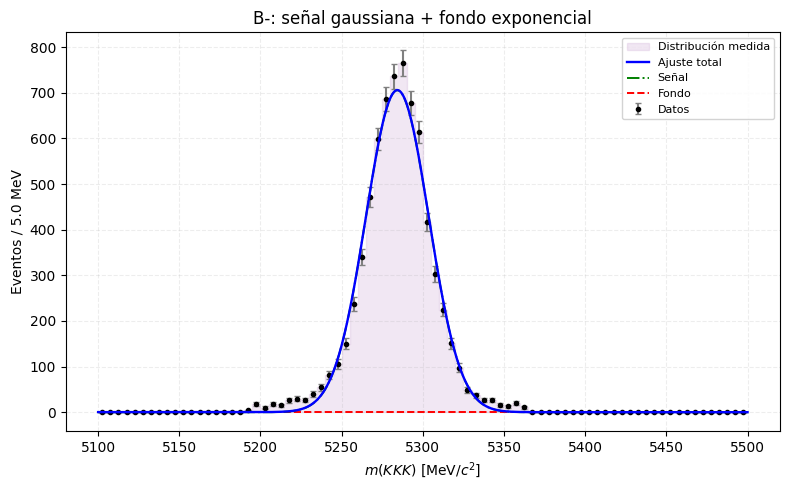

B-: N_señal = 6844 ± 83
B-: Chi2/ndf = 247.5/75

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\ajuste_bplus_señal_gaussiana_plus_fondo_exponencial.png


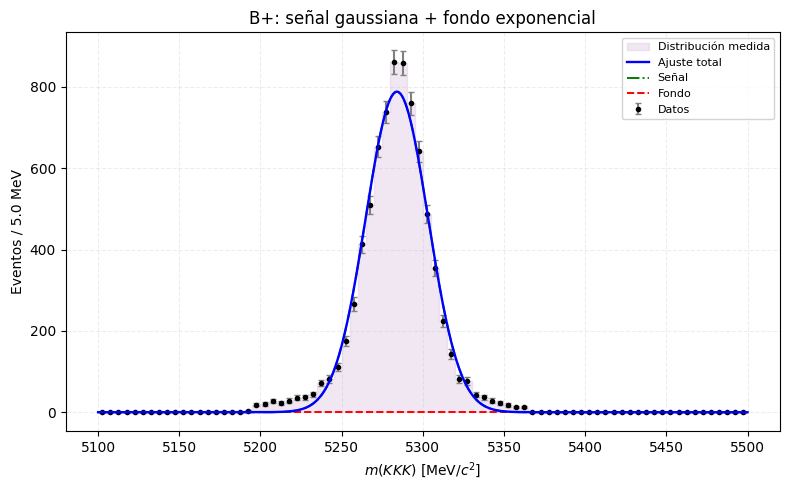

B+: N_señal = 7585 ± 87
B+: Chi2/ndf = 328.2/75



In [118]:
# Gráfica y ajuste de la masa invariante del mesón B-
nominal_fits = {}
for charge, label in [(-1, "B-"), (1, "B+")]:
    mass = fit_data.loc[fit_data["B_Charge"] == charge, "B_M_fit"]
    result = fit_mass_sample(mass, model_name="nominal")
    nominal_fits[charge] = result
    plot_fit_result(result, (f"{label}: señal gaussiana + fondo exponencial"))
    print(f"{label}: " f"N_señal = " f"{result['n_signal']:.0f} ± " f"{result['n_signal_error']:.0f}")
    print(f"{label}: "f"Chi2/ndf = "f"{result['chi2']:.1f}/"f"{result['ndf']}")
    print()

In [119]:
# Cálculo de la asimetría CP usando los valores extraidos del ajuste
nominal_asymetry = asymetry(nominal_fits)
print("N- = " f"{nominal_asymetry['N_minus']:.0f} ± " f"{nominal_asymetry['error_minus']:.0f}")
print("N+ = " f"{nominal_asymetry['N_plus']:.0f} ± " f"{nominal_asymetry['error_plus']:.0f}")
print("A_CP nominal = " f"{nominal_asymetry['asymmetry']:.6f} ± " f"{nominal_asymetry['uncertainty']:.6f}")
nominal_significance = (nominal_asymetry["asymmetry"]/nominal_asymetry["uncertainty"])
print("Significancia nominal =" f"{nominal_significance:.2f} $\sigma$")

N- = 6844 ± 83
N+ = 7585 ± 87
A_CP nominal = -0.051352 ± 0.008325
Significancia nominal =-6.17 $\sigma$


### Incertidumbres sistemáticas - Desafío 4

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\ajuste_bminus_señal_crystal_ball_plus_fondo_lineal.png


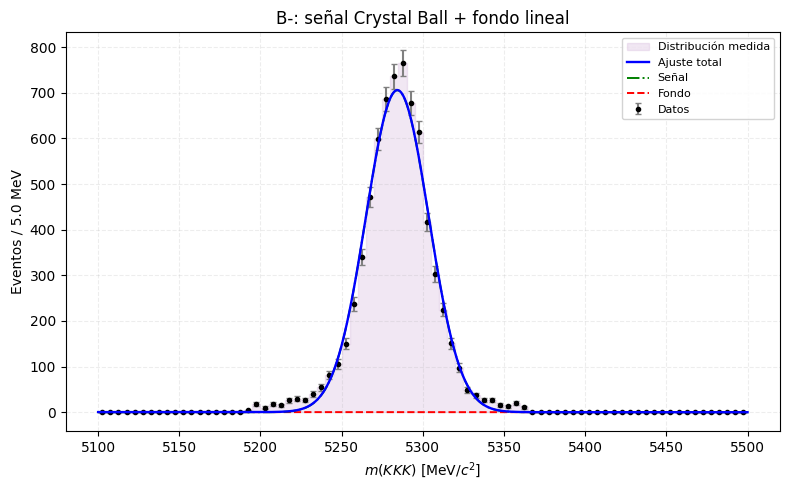

B-: N_señal = 6843 ± 83
B-: chi2/ndf = 247.3 / 73

Gráfica guardada en: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\graficas\ajuste_bplus_señal_crystal_ball_plus_fondo_lineal.png


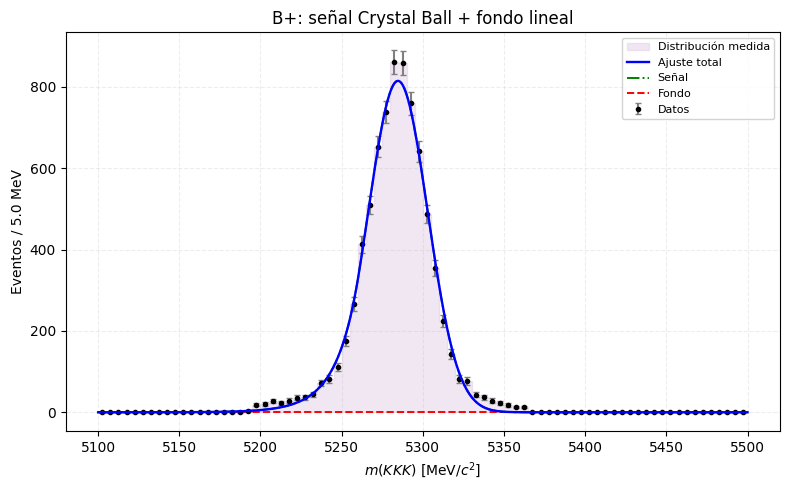

B+: N_señal = 7732 ± 89
B+: chi2/ndf = 198.3 / 73



In [120]:
# Gráfica y ajuste de la masa invariante del mesón B- usando otra función de ajuste
alternative_fits = {}
for charge, label in [(-1, "B-"), (1, "B+")]:
    mass = fit_data.loc[fit_data["B_Charge"] == charge, "B_M_fit"]
    result = fit_mass_sample(mass, model_name="alternative")
    alternative_fits[charge] = result
    plot_fit_result(result, (f"{label}: señal Crystal Ball + fondo lineal"))
    print(f"{label}: " f"N_señal = " f"{result['n_signal']:.0f} ± " f"{result['n_signal_error']:.0f}")
    print(f"{label}: " f"chi2/ndf = " f"{result['chi2']:.1f} / " f"{result['ndf']}")
    print()

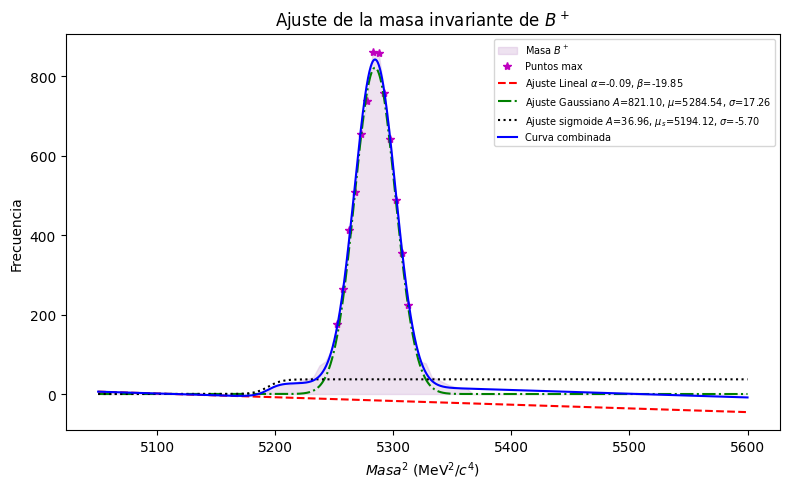

In [121]:
MASS_MIN, MASS_MAX, N_BINS = 5050.0, 5600.0, 110
BIN_WIDTH  = (MASS_MAX - MASS_MIN) / N_BINS
MASS_CENTER = (MASS_MIN + MASS_MAX) / 2.0

masses_Bp = fit_data.loc[fit_data["B_Charge"] == 1, "B_M"].values
masses_Bp = masses_Bp[(masses_Bp >= MASS_MIN) & (masses_Bp <= MASS_MAX)]

counts, edges = numpy.histogram(masses_Bp, bins=N_BINS, range=(MASS_MIN, MASS_MAX))
centers = (edges[:-1] + edges[1:]) / 2.0
# Puntos de los máximos locales (bins por encima del 20% del máximo)
mask_max = counts > 0.2 * counts.max()

# ── Modelos ──
def gauss(x, A, mu, sigma):
    return A * numpy.exp(-0.5 * ((x - mu) / sigma) ** 2)

def linear_bg(x, alpha, beta):
    return alpha * (x - MASS_CENTER) + beta

def sigmoid_bg(x, A, mu, sigma):
    return A / (1 + numpy.exp((x - mu) / sigma))

def combined(x, A_g, mu_g, sigma_g, alpha, beta, A_s, mu_s, sigma_s):
    return gauss(x, A_g, mu_g, sigma_g) + linear_bg(x, alpha, beta) + sigmoid_bg(x, A_s, mu_s, sigma_s)

p0 = [1000, 5280, 18, -0.05, 40, 30, 5170, -15]
try:
    popt, _ = cf(combined, centers, counts, p0=p0, maxfev=50000)
except Exception:
    popt = p0

x_dense = numpy.linspace(MASS_MIN, MASS_MAX, 2000)
A_g, mu_g, sg, al, be, A_s, mu_s, ss = popt

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor("white")
ax.fill_between(centers, counts, alpha=0.3, color="#c8a0d0", label=r"Masa $B^+$")
ax.plot(centers[mask_max], counts[mask_max], "m*", ms=6, label="Puntos max")
ax.plot(x_dense, linear_bg(x_dense, al, be), "r--", label=rf"Ajuste Lineal $\alpha$={al:.2f}, $\beta$={be:.2f}")
ax.plot(x_dense, gauss(x_dense, A_g, mu_g, sg), "g-.", label=rf"Ajuste Gaussiano $A$={A_g:.2f}, $\mu$={mu_g:.2f}, $\sigma$={sg:.2f}")
ax.plot(x_dense, sigmoid_bg(x_dense, A_s, mu_s, ss), "k:", label=rf"Ajuste sigmoide $A$={A_s:.2f}, $\mu_s$={mu_s:.2f}, $\sigma$={ss:.2f}")
ax.plot(x_dense, combined(x_dense, *popt), "b-", lw=1.5, label="Curva combinada")

ax.set_xlabel(r"$Masa^2\;(\mathrm{MeV}^2/c^4)$", style="italic")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Ajuste de la masa invariante de $B^+$")
ax.legend(fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.savefig("graficas/Ajuste_masa_Bp.png", dpi=1000, bbox_inches="tight")
plt.show()

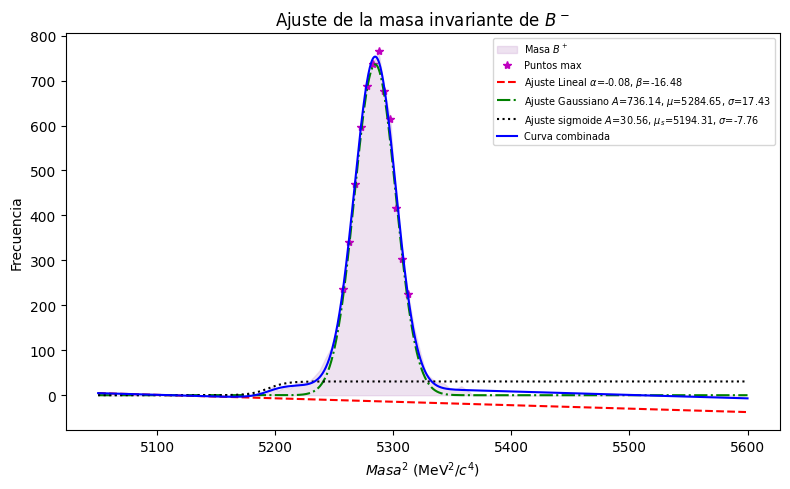

In [122]:
masses_Bm = fit_data.loc[fit_data["B_Charge"] == -1, "B_M"].values
masses_Bm = masses_Bm[(masses_Bm >= MASS_MIN) & (masses_Bm <= MASS_MAX)]

counts, edges = numpy.histogram(masses_Bm, bins=N_BINS, range=(MASS_MIN, MASS_MAX))
centers = (edges[:-1] + edges[1:]) / 2.0
# Puntos de los máximos locales (bins por encima del 20% del máximo)
mask_max = counts > 0.2 * counts.max()

# ── Modelos ──
def gauss(x, A, mu, sigma):
    return A * numpy.exp(-0.5 * ((x - mu) / sigma) ** 2)

def linear_bg(x, alpha, beta):
    return alpha * (x - MASS_CENTER) + beta

def sigmoid_bg(x, A, mu, sigma):
    return A / (1 + numpy.exp((x - mu) / sigma))

def combined(x, A_g, mu_g, sigma_g, alpha, beta, A_s, mu_s, sigma_s):
    return gauss(x, A_g, mu_g, sigma_g) + linear_bg(x, alpha, beta) + sigmoid_bg(x, A_s, mu_s, sigma_s)

p0 = [1000, 5280, 18, -0.05, 40, 30, 5170, -15]
try:
    popt, _ = cf(combined, centers, counts, p0=p0, maxfev=50000)
except Exception:
    popt = p0

x_dense = numpy.linspace(MASS_MIN, MASS_MAX, 2000)
A_g, mu_g, sg, al, be, A_s, mu_s, ss = popt

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor("white")
ax.fill_between(centers, counts, alpha=0.3, color="#c8a0d0", label=r"Masa $B^+$")
ax.plot(centers[mask_max], counts[mask_max], "m*", ms=6, label="Puntos max")
ax.plot(x_dense, linear_bg(x_dense, al, be), "r--", label=rf"Ajuste Lineal $\alpha$={al:.2f}, $\beta$={be:.2f}")
ax.plot(x_dense, gauss(x_dense, A_g, mu_g, sg), "g-.", label=rf"Ajuste Gaussiano $A$={A_g:.2f}, $\mu$={mu_g:.2f}, $\sigma$={sg:.2f}")
ax.plot(x_dense, sigmoid_bg(x_dense, A_s, mu_s, ss), "k:", label=rf"Ajuste sigmoide $A$={A_s:.2f}, $\mu_s$={mu_s:.2f}, $\sigma$={ss:.2f}")
ax.plot(x_dense, combined(x_dense, *popt), "b-", lw=1.5, label="Curva combinada")

ax.set_xlabel(r"$Masa^2\;(\mathrm{MeV}^2/c^4)$", style="italic")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Ajuste de la masa invariante de $B^-$")
ax.legend(fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.savefig("graficas/Ajuste_masa_Bm.png", dpi=1000, bbox_inches="tight")
plt.show()

In [123]:
# Cálculo de la asimetría CP usando los valores extraídos del ajuste
alternative_asymmetry = asymetry(alternative_fits)
print("N- alternativo = " f"{alternative_asymmetry['N_minus']:.0f} ±" f"{alternative_asymmetry['error_minus']:.0f}")
print("N+ alternativo = " f"{alternative_asymmetry['N_plus']:.0f} ±" f"{alternative_asymmetry['error_plus']:.0f}")
print("A_CP alternativo = "f"{alternative_asymmetry['asymmetry']:.6f} ± "f"{alternative_asymmetry['uncertainty']}")
alternative_significance = (alternative_asymmetry["asymmetry"]/alternative_asymmetry["uncertainty"])
print("Significancia alternativa = "f"{alternative_significance:.2f} σ")

N- alternativo = 6843 ±83
N+ alternativo = 7732 ±89
A_CP alternativo = -0.060984 ± 0.00830280684014718
Significancia alternativa = -7.34 σ


In [124]:
# Cálculo de la incertidumbre sistemática
systematic_uncertainty = abs(alternative_asymmetry["asymmetry"]-nominal_asymetry["asymmetry"])
total_uncertainty = numpy.sqrt(nominal_asymetry["uncertainty"]**2 + systematic_uncertainty**2)
print("A_CP nominal = "f"{nominal_asymetry['asymmetry']:.6f}")
print("A_CP alternativo = "f"{alternative_asymmetry['asymmetry']:.6f}")
print("Incertidumbre estadística = "f"{nominal_asymetry['uncertainty']:.6f}")
print("Incertidumbre sistemática por modelo = "f"{systematic_uncertainty:.6f}")
print("Incertidumbre total = "f"{total_uncertainty:.6f}")
print("\nResultado:")
print(
    "A_CP = "
    f"{nominal_asymetry['asymmetry']:.6f}"
    f"± {nominal_asymetry['uncertainty']:.6f}"
    f"(estadística )"
    f"± {systematic_uncertainty:.6f}"
    f"(sistemática)"
)

A_CP nominal = -0.051352
A_CP alternativo = -0.060984
Incertidumbre estadística = 0.008325
Incertidumbre sistemática por modelo = 0.009632
Incertidumbre total = 0.012731

Resultado:
A_CP = -0.051352± 0.008325(estadística )± 0.009632(sistemática)
